<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

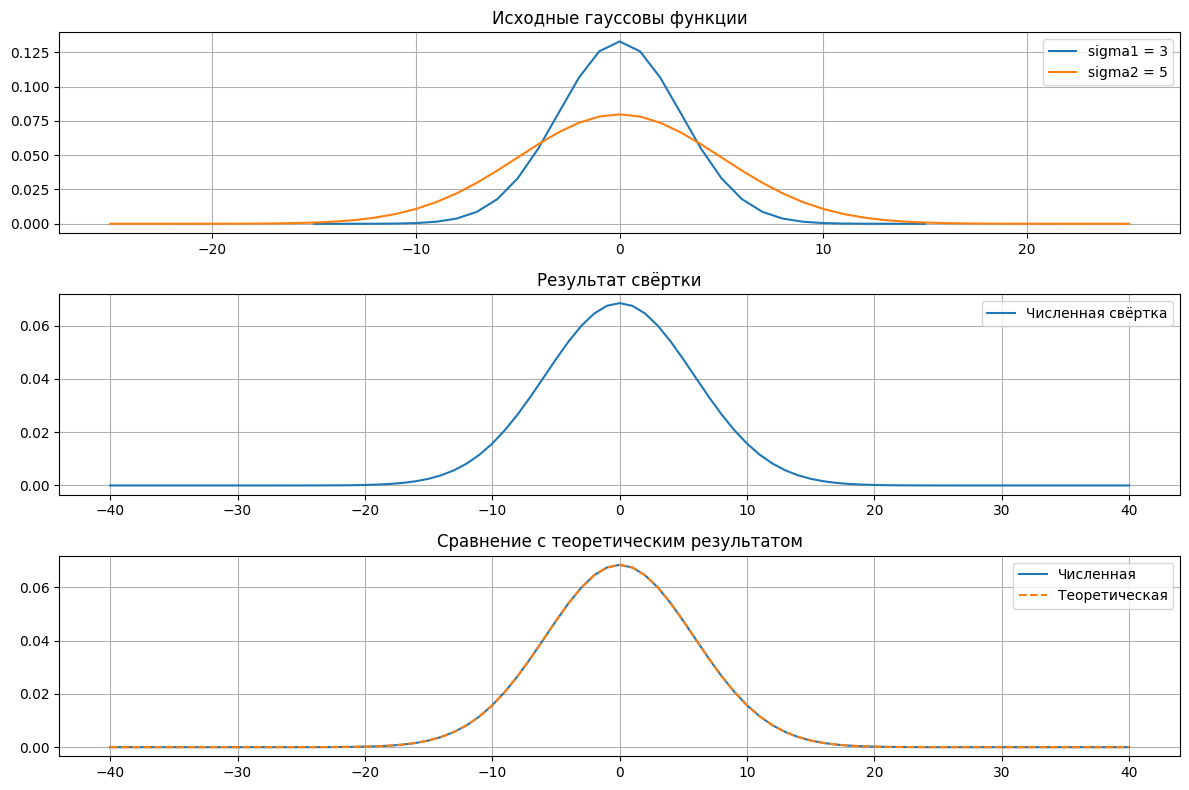

sigma_theory = 5.831
MSE = 2.42e-16


In [13]:
sigma1 = 3
sigma2 = 5

M1 = 10 * sigma1 + 1
M2 = 10 * sigma2 + 1

g1 = signal.windows.gaussian(M1, std=sigma1)
g2 = signal.windows.gaussian(M2, std=sigma2)

g1 = g1 / np.sum(g1)
g2 = g2 / np.sum(g2)

conv_num = np.convolve(g1, g2, mode='full')

t1 = np.arange(M1) - M1 // 2
t2 = np.arange(M2) - M2 // 2
t_conv = np.arange(len(conv_num)) - (M1 // 2 + M2 // 2)

sigma_theory = np.sqrt(sigma1**2 + sigma2**2)
conv_theory = np.exp(-t_conv**2 / (2 * sigma_theory**2))
conv_theory = conv_theory / np.sum(conv_theory)

mse = np.mean((conv_num - conv_theory) ** 2)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t1, g1, label=f'sigma1 = {sigma1}')
plt.plot(t2, g2, label=f'sigma2 = {sigma2}')
plt.title('Исходные гауссовы функции')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_conv, conv_num, label='Численная свёртка')
plt.title('Результат свёртки')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_conv, conv_num, label='Численная')
plt.plot(t_conv, conv_theory, '--', label='Теоретическая')
plt.title('Сравнение с теоретическим результатом')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f'sigma_theory = {sigma_theory:.3f}')
print(f'MSE = {mse:.2e}')


**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

свёртка станет шире и сглаженнее, а максимум ниже

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

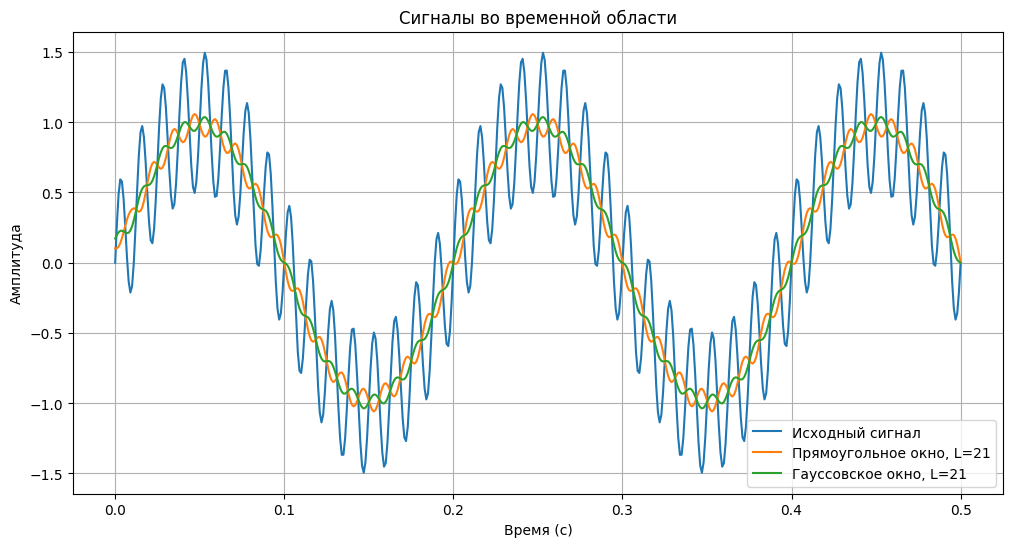

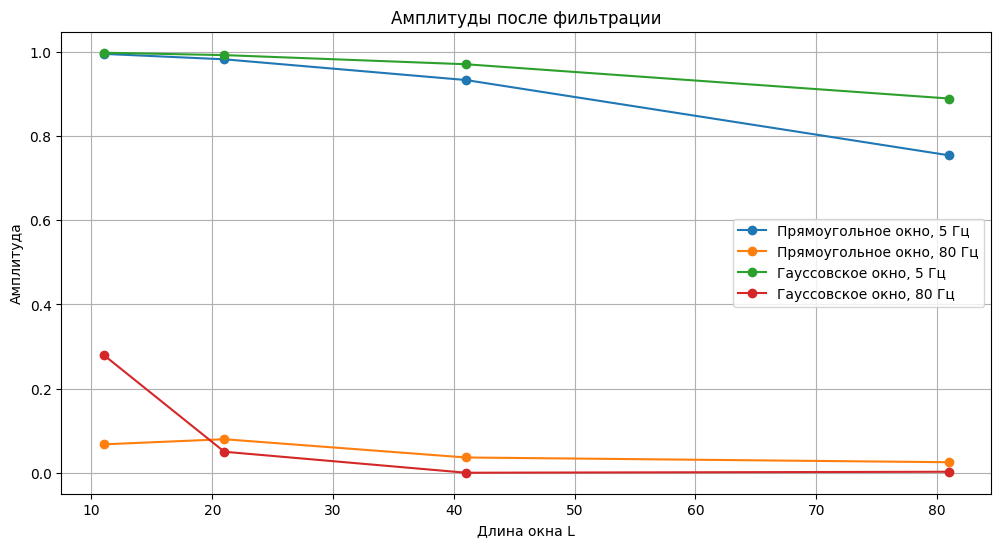

L=11: rect -> A5=0.995, A80=0.068; gauss -> A5=0.998, A80=0.280
L=21: rect -> A5=0.982, A80=0.080; gauss -> A5=0.992, A80=0.050
L=41: rect -> A5=0.933, A80=0.037; gauss -> A5=0.970, A80=0.000
L=81: rect -> A5=0.754, A80=0.025; gauss -> A5=0.889, A80=0.003


In [14]:
fs = 1000
t = np.arange(0, 2, 1 / fs)
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)

L_values = [11, 21, 41, 81]
demo_L = 21

def fft_amplitude(sig, freq, fs):
    n = len(sig)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    X = np.fft.rfft(sig)
    amp = 2 * np.abs(X) / n
    idx = np.argmin(np.abs(freqs - freq))
    return amp[idx]

rect_amp_5 = []
rect_amp_80 = []
gauss_amp_5 = []
gauss_amp_80 = []

for L in L_values:
    h_rect = signal.windows.boxcar(L)
    h_rect = h_rect / np.sum(h_rect)

    h_gauss = signal.windows.gaussian(L, std=L / 5)
    h_gauss = h_gauss / np.sum(h_gauss)

    y_rect = np.convolve(x, h_rect, mode='same')
    y_gauss = np.convolve(x, h_gauss, mode='same')

    rect_amp_5.append(fft_amplitude(y_rect, 5, fs))
    rect_amp_80.append(fft_amplitude(y_rect, 80, fs))
    gauss_amp_5.append(fft_amplitude(y_gauss, 5, fs))
    gauss_amp_80.append(fft_amplitude(y_gauss, 80, fs))

    if L == demo_L:
        y_rect_demo = y_rect
        y_gauss_demo = y_gauss

mask = t <= 0.5

plt.figure(figsize=(12, 6))
plt.plot(t[mask], x[mask], label='Исходный сигнал')
plt.plot(t[mask], y_rect_demo[mask], label=f'Прямоугольное окно, L={demo_L}')
plt.plot(t[mask], y_gauss_demo[mask], label=f'Гауссовское окно, L={demo_L}')
plt.title('Сигналы во временной области')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(L_values, rect_amp_5, 'o-', label='Прямоугольное окно, 5 Гц')
plt.plot(L_values, rect_amp_80, 'o-', label='Прямоугольное окно, 80 Гц')
plt.plot(L_values, gauss_amp_5, 'o-', label='Гауссовское окно, 5 Гц')
plt.plot(L_values, gauss_amp_80, 'o-', label='Гауссовское окно, 80 Гц')
plt.title('Амплитуды после фильтрации')
plt.xlabel('Длина окна L')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.legend()
plt.show()

for i, L in enumerate(L_values):
    print(
        f'L={L}: rect -> A5={rect_amp_5[i]:.3f}, A80={rect_amp_80[i]:.3f}; '
        f'gauss -> A5={gauss_amp_5[i]:.3f}, A80={gauss_amp_80[i]:.3f}'
    )


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

1) окно Гаусса лучше подавляет высокую частоту и при этом лучше сохраняет низкую. Исключение здесь только при L в районе 10, где прямоугольное окно подавило 80 Гц чуть сильнее
2) Амплитуда 80 Гц падает в 10 раз примерно при L=41. Для гауссовского окна это происходит уже примерно при L=21, а при L=41 подавление становится очень сильным
3) При увеличении длины окна высокочастотная составляющая подавляется сильнее, но начинает уменьшаться и амплитуда низкой частоты. Более чем на 10% она уменьшается примерно при L=81 для обоих окон


## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

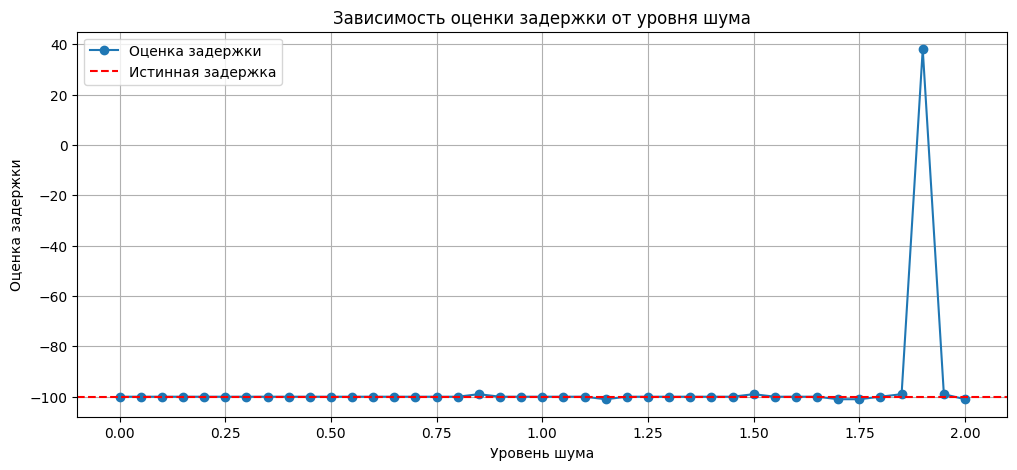

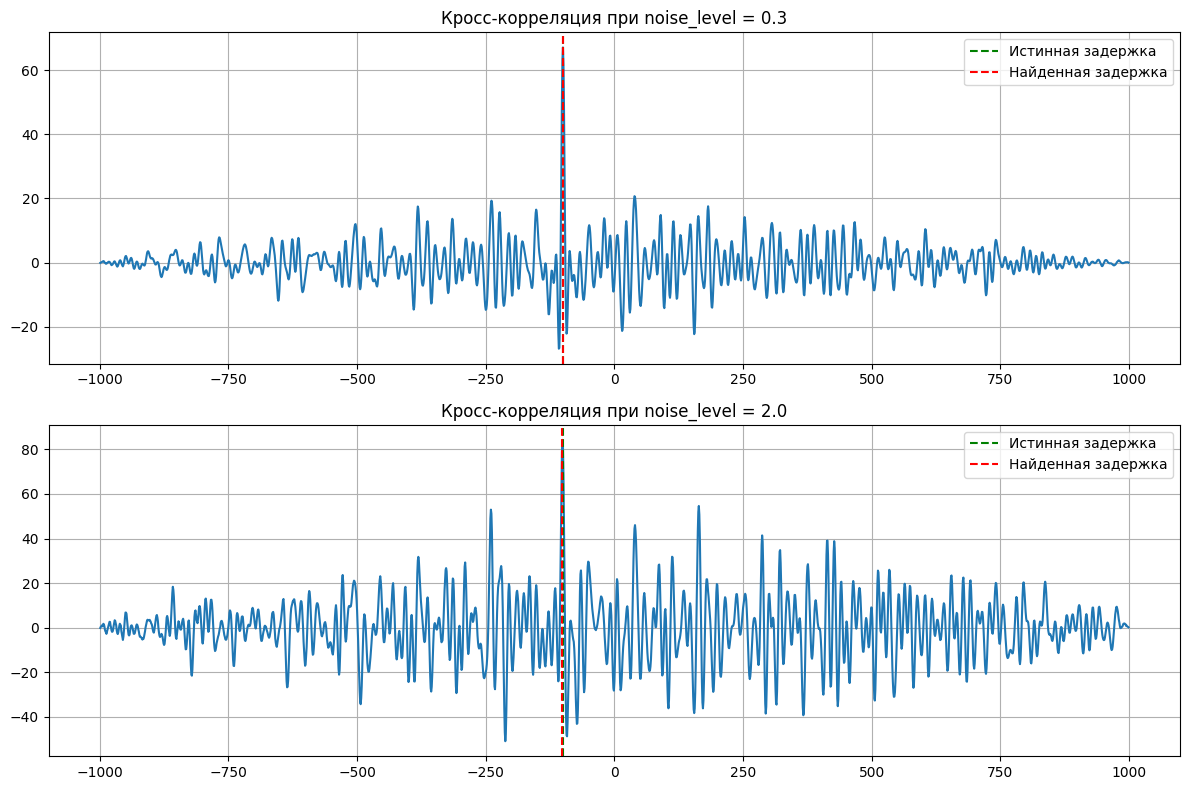

noise_level=0.00, delay_est=-100
noise_level=0.05, delay_est=-100
noise_level=0.10, delay_est=-100
noise_level=0.15, delay_est=-100
noise_level=0.20, delay_est=-100
noise_level=0.25, delay_est=-100
noise_level=0.30, delay_est=-100
noise_level=0.35, delay_est=-100
noise_level=0.40, delay_est=-100
noise_level=0.45, delay_est=-100
noise_level=0.50, delay_est=-100
noise_level=0.55, delay_est=-100
noise_level=0.60, delay_est=-100
noise_level=0.65, delay_est=-100
noise_level=0.70, delay_est=-100
noise_level=0.75, delay_est=-100
noise_level=0.80, delay_est=-100
noise_level=0.85, delay_est=-99
noise_level=0.90, delay_est=-100
noise_level=0.95, delay_est=-100
noise_level=1.00, delay_est=-100
noise_level=1.05, delay_est=-100
noise_level=1.10, delay_est=-100
noise_level=1.15, delay_est=-101
noise_level=1.20, delay_est=-100
noise_level=1.25, delay_est=-100
noise_level=1.30, delay_est=-100
noise_level=1.35, delay_est=-100
noise_level=1.40, delay_est=-100
noise_level=1.45, delay_est=-100
noise_level

In [15]:
np.random.seed(42)

fs = 1000
t = np.arange(0, 1, 1 / fs)

freqs = np.random.uniform(10, 100, 100)
amps = np.random.uniform(0.5, 1.5, 100)
phases = np.random.uniform(0, 2 * np.pi, 100)

x = np.zeros_like(t)
for f, a, p in zip(freqs, amps, phases):
    x += a * np.sin(2 * np.pi * f * t + p)

x = x / np.max(np.abs(x))

delay = 100
true_delay = -delay
noise_levels = np.linspace(0, 2, 41)

delay_estimates = []
errors = []
corr_examples = {}

for noise_level in noise_levels:
    y = np.concatenate([np.zeros(delay), x[:-delay]])
    y = y + noise_level * np.random.randn(len(x))

    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    delay_est = lags[np.argmax(corr)]

    delay_estimates.append(delay_est)
    errors.append(abs(delay_est - true_delay))

    if np.isclose(noise_level, 0.3) or np.isclose(noise_level, 2.0):
        corr_examples[round(noise_level, 1)] = (lags, corr, delay_est)

plt.figure(figsize=(12, 5))
plt.plot(noise_levels, delay_estimates, 'o-', label='Оценка задержки')
plt.axhline(true_delay, color='r', linestyle='--', label='Истинная задержка')
plt.xlabel('Уровень шума')
plt.ylabel('Оценка задержки')
plt.title('Зависимость оценки задержки от уровня шума')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
lags, corr, delay_est = corr_examples[0.3]
plt.plot(lags, corr)
plt.axvline(true_delay, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 0.3')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
lags, corr, delay_est = corr_examples[2.0]
plt.plot(lags, corr)
plt.axvline(true_delay, color='g', linestyle='--', label='Истинная задержка')
plt.axvline(delay_est, color='r', linestyle='--', label='Найденная задержка')
plt.title('Кросс-корреляция при noise_level = 2.0')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

for noise_level, delay_est in zip(noise_levels, delay_estimates):
    print(f'noise_level={noise_level:.2f}, delay_est={delay_est}')


**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

1) Точность оценки задержки падает, но до noise_level примерно 1.8 оценка остаётся близкой к истинной. Ошибка больше 10% впервые появляется примерно при noise_level = 1.9
В диапазоне шума до 2 оценка не становится практически неотличимой от 0
3) При высоком уровне шума появляются ложные пики, потому что шум создаёт случайные локальные совпадения, и максимум корреляции может сместиться с истинного положения


## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

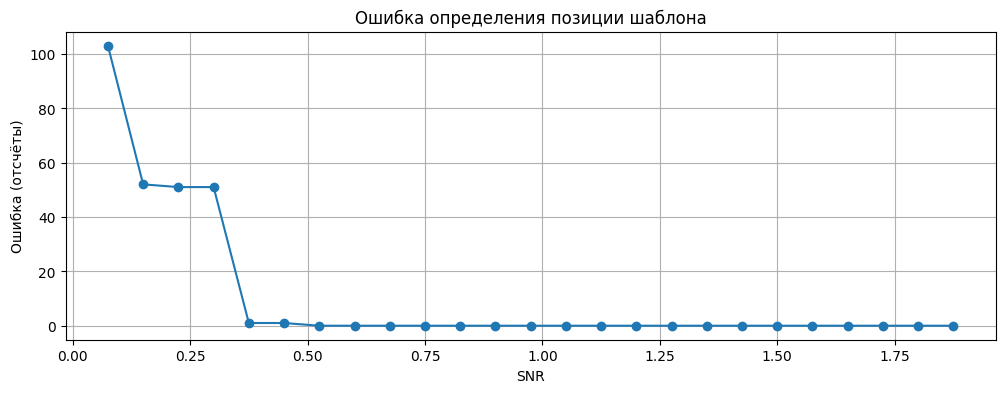

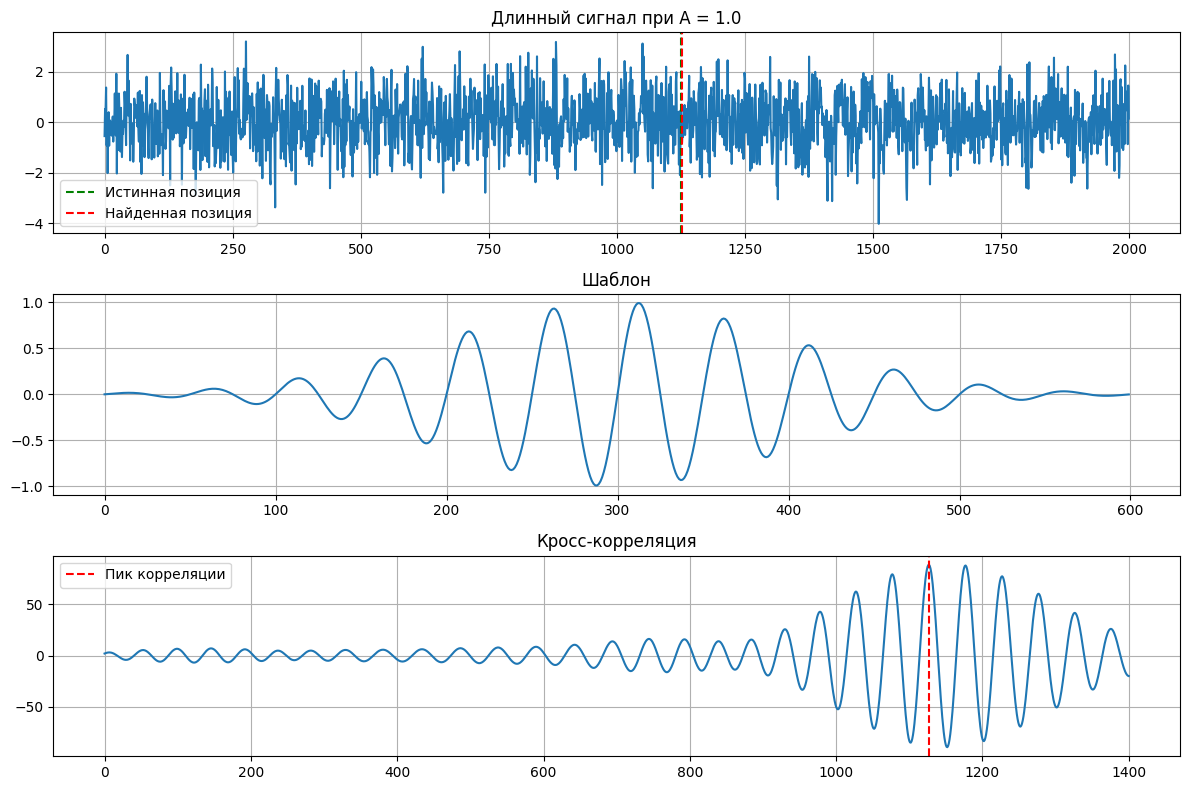

A=0.2, SNR=0.075, error=103
A=0.4, SNR=0.150, error=52
A=0.6, SNR=0.225, error=51
A=0.8, SNR=0.300, error=51
A=1.0, SNR=0.375, error=1
A=1.2, SNR=0.450, error=1
A=1.4, SNR=0.525, error=0
A=1.6, SNR=0.600, error=0
A=1.8, SNR=0.675, error=0
A=2.0, SNR=0.750, error=0
A=2.2, SNR=0.825, error=0
A=2.4, SNR=0.900, error=0
A=2.6, SNR=0.975, error=0
A=2.8, SNR=1.050, error=0
A=3.0, SNR=1.125, error=0
A=3.2, SNR=1.200, error=0
A=3.4, SNR=1.275, error=0
A=3.6, SNR=1.350, error=0
A=3.8, SNR=1.425, error=0
A=4.0, SNR=1.500, error=0
A=4.2, SNR=1.575, error=0
A=4.4, SNR=1.650, error=0
A=4.6, SNR=1.725, error=0
A=4.8, SNR=1.800, error=0
A=5.0, SNR=1.875, error=0


In [16]:
np.random.seed(42)

fs = 1000
sigma = 100

n_template = int(6 * sigma)
t_template = np.arange(n_template) - n_template // 2

envelope = np.exp(-t_template**2 / (2 * sigma**2))
template = envelope * np.sin(2 * np.pi * 20 * t_template / fs)

long_len = 2000
insert_pos = np.random.randint(0, long_len - len(template))
noise = np.random.randn(long_len)

A_values = np.linspace(0.2, 5, 25)
snr_values = []
errors = []

for A in A_values:
    long_signal = noise.copy()
    long_signal[insert_pos:insert_pos + len(template)] += A * template

    corr = np.correlate(long_signal, template, mode='valid')
    pos_est = np.argmax(corr)

    snr = np.std(A * template) / np.std(noise)
    snr_values.append(snr)
    errors.append(abs(pos_est - insert_pos))

A_vis = 1.0
long_signal_vis = noise.copy()
long_signal_vis[insert_pos:insert_pos + len(template)] += A_vis * template

corr_vis = np.correlate(long_signal_vis, template, mode='valid')
pos_est_vis = np.argmax(corr_vis)

plt.figure(figsize=(12, 4))
plt.plot(snr_values, errors, 'o-')
plt.title('Ошибка определения позиции шаблона')
plt.xlabel('SNR')
plt.ylabel('Ошибка (отсчёты)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(long_signal_vis)
plt.axvline(insert_pos, color='g', linestyle='--', label='Истинная позиция')
plt.axvline(pos_est_vis, color='r', linestyle='--', label='Найденная позиция')
plt.title(f'Длинный сигнал при A = {A_vis}')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(template)
plt.title('Шаблон')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(corr_vis)
plt.axvline(pos_est_vis, color='r', linestyle='--', label='Пик корреляции')
plt.title('Кросс-корреляция')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

for A, snr, err in zip(A_values, snr_values, errors):
    print(f'A={A:.1f}, SNR={snr:.3f}, error={err}')


**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

при SNR меньше примерно 0.4-1.0


## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [17]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

zsh:1: command not found: wget
zsh:1: command not found: wget


Позиция фрагмента: 279235 отсчётов
Время: 6.332 с


/var/folders/z9/5252knn95hj09b0trwfzfysr0000gn/T/ipykernel_94458/254656225.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_full, full_audio = wavfile.read(full_path)
/var/folders/z9/5252knn95hj09b0trwfzfysr0000gn/T/ipykernel_94458/254656225.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_frag, fragment = wavfile.read(fragment_path)


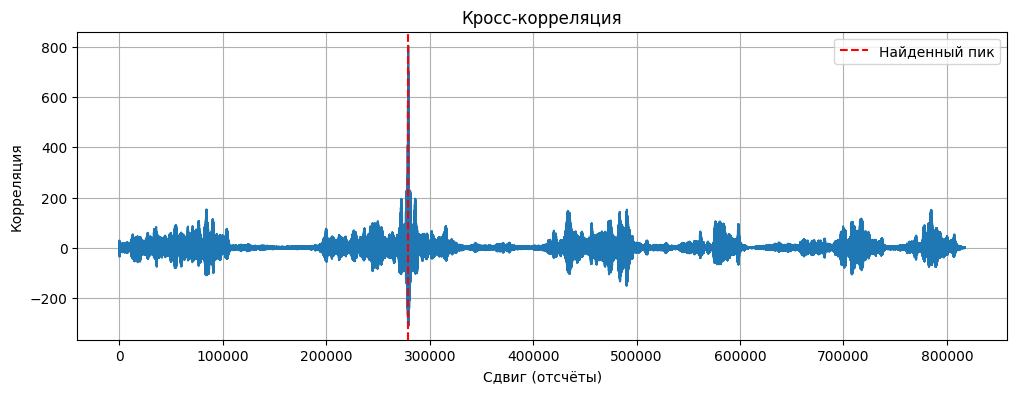

Количество заметных пиков: 1
Пики по времени (с): [np.float64(6.332)]
Исходный фрагмент:


Найденный участок:


In [18]:
from pathlib import Path

full_path = '../data/full_audio.wav'
fragment_path = '../data/fragment.wav'

fs_full, full_audio = wavfile.read(full_path)
fs_frag, fragment = wavfile.read(fragment_path)

full_audio = full_audio.mean(axis=1)
fragment = fragment.mean(axis=1)

full_audio = full_audio.astype(float)
fragment = fragment.astype(float)

full_audio = full_audio - np.mean(full_audio)
fragment = fragment - np.mean(fragment)

full_audio = full_audio / np.max(np.abs(full_audio))
fragment = fragment / np.max(np.abs(fragment))

corr = signal.correlate(full_audio, fragment, mode='valid')
start_idx = np.argmax(corr)
start_time = start_idx / fs_full

print(f'Позиция фрагмента: {start_idx} отсчётов')
print(f'Время: {start_time:.3f} с')

plt.figure(figsize=(12, 4))
plt.plot(corr)
plt.axvline(start_idx, color='r', linestyle='--', label='Найденный пик')
plt.title('Кросс-корреляция')
plt.xlabel('Сдвиг (отсчёты)')
plt.ylabel('Корреляция')
plt.grid(True)
plt.legend()
plt.show()

fragment_len = len(fragment)
found_fragment = full_audio[start_idx:start_idx + fragment_len]

corr_norm = corr / np.max(np.abs(corr))
peaks, properties = signal.find_peaks(corr_norm, height=0.45, distance=fragment_len // 2)

print(f'Количество заметных пиков: {len(peaks)}')
print('Пики по времени (с):', [round(p / fs_full, 3) for p in peaks])

print('Исходный фрагмент:')
display(Audio(fragment, rate=fs_frag))

print('Найденный участок:')
display(Audio(found_fragment, rate=fs_full))


**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

1) Чтобы убрать влияние общего уровня громкости и смещения, и сравнивать именно форму сигнала
2) Один раз, примерно на 6.332 с. Сильных ложных максимумов нет
3) Выраженного пика не будет
